# Analysis on STD Data in Different Communitites

In [18]:
#Packages

#Data Manipulation
import numpy as np
import pandas as pd
import missingno as msno


#Data Visualization
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

## About the Data 
Link to dataset: https://wonder.cdc.gov/controller/datarequest/D128 <br>
This data set is from the CDC website. This is their description of the data: <br>
"This dataset contains Sexually Transmitted Disease (STD) morbidity case reports reported to the National Center for HIV/AIDS, Viral Hepatitis, STD, and TB Prevention (NCHHSTP), Centers for Disease Control and Prevention (CDC), for the 50 United States, the District of Columbia and Puerto Rico. The number of cases and disease incidence rates are reported by age group, race/ethnicity and sex of patient, year, type of STD (Chlamydia, Gonorrhea, Primary and Secondary Syphilis), and area of report." <br>
I chose this dataset because of its rich demographic breakdowns, which allow for exploration of disparities across communities. My interest was sparked by a UMass study on the NamUs database of missing persons, which found that Indigenous women go missing at disproportionately higher rates than women of other ethnicities. This led me to wonder: Do similar disparities exist in STD data across different demographics? <br>

## Research Questions 

1. Which races/ethnicities report the highest and lowest rates of STDs?
2. Are certain STDs more prevalent within specific demographic groups (e.g., race/ethnicity, age, or sex)? How do these patterns differ across communities?

3. What differences exist in STD rates between men and women? How do these compare across different age groups?

4. Does it fluctuate over the years?

5. What broader insights can we uncover from these patterns? For example, do the disparities highlight potential gaps in healthcare access, awareness, or preventive measures?

Through this project, I aim to investigate that question while also uncovering broader trends in STD morbidity across age, race/ethnicity, and sex. <br>

* Note: Rate is per 100,000

### Import your data 

In [21]:
df = pd.read_csv('cdc_std_data.csv')
df

,Notes,Year,Year Code,Race/Ethnicity,Race/Ethnicity Code,Age,Age Code,Sex,Sex Code,Disease,Disease Code,STD Cases,Population,Rate
0,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Female,F,Chlamydia,274.0,189.0,296512.0,63.74
1,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Female,F,Gonorrhea,280.0,31.0,301607.0,10.28
2,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Male,M,Chlamydia,274.0,21.0,305610.0,6.87
3,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Male,M,Gonorrhea,280.0,8.0,310831.0,2.57
4,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,15-19 years,15-19,Female,F,Chlamydia,274.0,2385.0,91364.0,2610.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,reports. More information: http://wonder.cdc.g...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3909,9. If the total number of cases in a state in ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,cases of that disease in that state in that ye...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3911,those cases of that disease in that state in t...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2: Explore Data

In [23]:
#Viewing head an tail
df

,Notes,Year,Year Code,Race/Ethnicity,Race/Ethnicity Code,Age,Age Code,Sex,Sex Code,Disease,Disease Code,STD Cases,Population,Rate
0,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Female,F,Chlamydia,274.0,189.0,296512.0,63.74
1,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Female,F,Gonorrhea,280.0,31.0,301607.0,10.28
2,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Male,M,Chlamydia,274.0,21.0,305610.0,6.87
3,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,0-14 years,0-14,Male,M,Gonorrhea,280.0,8.0,310831.0,2.57
4,NaN,1996.0,1996.0,American Indian or Alaska Native,1002-5,15-19 years,15-19,Female,F,Chlamydia,274.0,2385.0,91364.0,2610.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,reports. More information: http://wonder.cdc.g...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3909,9. If the total number of cases in a state in ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,cases of that disease in that state in that ye...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3911,those cases of that disease in that state in t...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3913 entries, 0 to 3912
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Notes                57 non-null     object 
 1   Year                 3856 non-null   float64
 2   Year Code            3856 non-null   float64
 3   Race/Ethnicity       3856 non-null   object 
 4   Race/Ethnicity Code  3856 non-null   object 
 5   Age                  3856 non-null   object 
 6   Age Code             3856 non-null   object 
 7   Sex                  3856 non-null   object 
 8   Sex Code             3856 non-null   object 
 9   Disease              3856 non-null   object 
 10  Disease Code         3856 non-null   float64
 11  STD Cases            3856 non-null   float64
 12  Population           3856 non-null   float64
 13  Rate                 3856 non-null   float64
dtypes: float64(6), object(8)
memory usage: 428.1+ KB


In [25]:
#Describe 
df.describe()

,Year,Year Code,Disease Code,STD Cases,Population,Rate
count,3856.000000,3856.000000,3856.000000,3856.000000,3.856000e+03,3856.000000
mean,2005.001297,2005.001297,287.243257,4856.806017,4.218591e+06,311.527329
std,5.485294,5.485294,15.472463,13429.586353,8.577486e+06,810.365097
min,1996.000000,1996.000000,274.000000,1.000000,7.348200e+04,0.010000
25%,2000.000000,2000.000000,274.000000,67.000000,5.111710e+05,4.347500
50%,2005.000000,2005.000000,280.000000,416.000000,1.531458e+06,31.335000
75%,2010.000000,2010.000000,310.000000,2937.500000,5.692569e+06,184.317500
max,2014.000000,2014.000000,310.000000,130068.000000,5.572729e+07,7761.960000


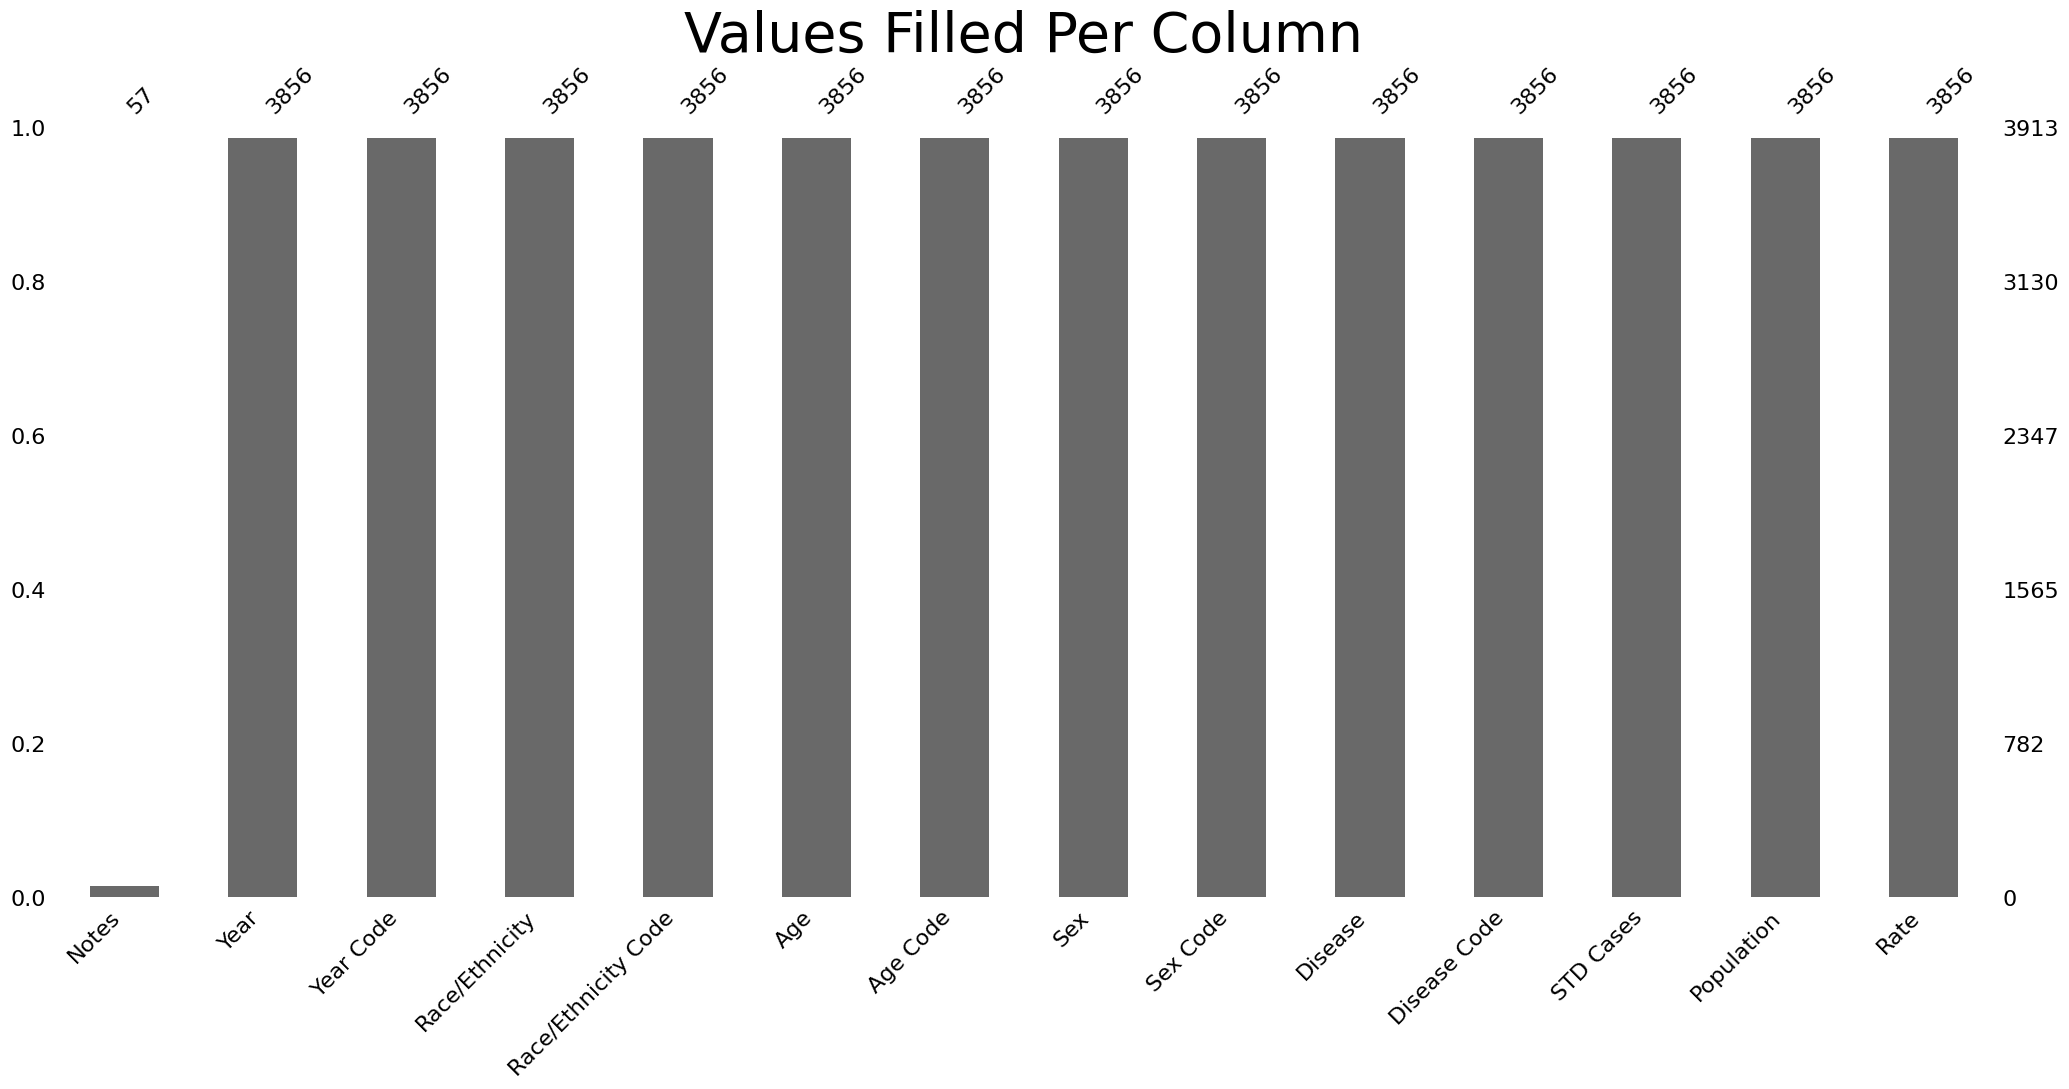

In [26]:
#missingno
#Observing volume of null values
msno.bar(df)
plt.title("Values Filled Per Column", fontsize = 40)
plt.show()

In [27]:
print('Printing unique values for each column:')
column_names = list(df.columns)
for name in column_names:
    print(f'{name}:')
    print(df[name].unique())
    print()

Printing unique values for each column:
Notes:
[nan '---'
 'Dataset: Selected STDs by Age, Race/Ethnicity, and Sex, 1996-2014'
 'Query Parameters:' 'Title: cdc_std_data'
 'Age: 0-14 years; 15-19 years; 20-24 years; 25-29 years; 30-34 years; 35-39 years; 40+ years'
 'Race/Ethnicity: American Indian or Alaska Native; Asian or Pacific Islander; Black or African American; Hispanic; White'
 'Sex: Female; Male' 'State: The United States and D.C. (00)'
 'Group By: Year; Race/Ethnicity; Age; Sex; Disease' 'Show Totals: False'
 'Show Zero Values: False' 'Show Suppressed: False'
 'Calculate Rates Per: 100,000'
 'Help: See http://wonder.cdc.gov/wonder/help/std-race-age-frame.html for more information.'
 'Query Date: Aug 30, 2025 8:36:48 PM'
 'Suggested Citation: US Department of Health and Human Services, Centers for Disease Control and Prevention, National Center for'
 'HIV, STD and TB Prevention (NCHSTP), Division of STD/HIV Prevention, Sexually Transmitted Disease Morbidity for selected STDs b

Examining the data, we can see it is pretty clean and well-formatted. After trimming some fat, we can commence analysis.

### 3. Transform the data
1. Delete "Notes", "State Code", "Race/Ethnicity Code", "Age"
2. Delete remaining NaNs (remnant of "Notes")

In [30]:
df_trim = df.drop(columns = ["Notes", "Disease Code", "Race/Ethnicity Code", "Age", "Year Code"])
df_trim = df_trim.dropna()
df_trim

,Year,Race/Ethnicity,Age Code,Sex,Sex Code,Disease,STD Cases,Population,Rate
0,1996.0,American Indian or Alaska Native,0-14,Female,F,Chlamydia,189.0,296512.0,63.74
1,1996.0,American Indian or Alaska Native,0-14,Female,F,Gonorrhea,31.0,301607.0,10.28
2,1996.0,American Indian or Alaska Native,0-14,Male,M,Chlamydia,21.0,305610.0,6.87
3,1996.0,American Indian or Alaska Native,0-14,Male,M,Gonorrhea,8.0,310831.0,2.57
4,1996.0,American Indian or Alaska Native,15-19,Female,F,Chlamydia,2385.0,91364.0,2610.44
...,...,...,...,...,...,...,...,...,...
3851,2014.0,White,40+,Female,F,Gonorrhea,2259.0,55727294.0,4.05
3852,2014.0,White,40+,Female,F,Primary and Secondary Syphilis,100.0,55727294.0,0.18
3853,2014.0,White,40+,Male,M,Chlamydia,9211.0,50926628.0,18.09
3854,2014.0,White,40+,Male,M,Gonorrhea,8382.0,50926628.0,16.46


### 4. Analysis
Now that our data is ready, we can start analysis. 